In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from statsmodels.regression.linear_model import OLS


In [20]:
data_2022_2025 = pd.read_parquet("../data/processed/2022-2025_factor_construction.parquet")
data_2022_2025 = data_2022_2025[data_2022_2025["in_universe"] == 1]
data_2022_2025

,timestamp,symbol,in_universe,z_momentum_7d,z_momentum_14d,z_momentum_30d,z_momentum_90d,z_reversal_1d,z_reversal_3d,z_vol_7d,z_vol_14d,z_vol_30d,z_vol_of_vol_14d,log_return,z_amihud_14d,z_amihud_30d,fwd_1d,fwd_5d,fwd_14d
0,2022-01-01 00:00:00+00:00,BTC/USDT,1,-0.218301,-0.518497,0.023830,-0.266958,-0.394565,-0.471287,-1.277533,-1.382781,-1.798911,-1.080754,0.032060,-1.290804,-1.346109,-0.009188,-0.102294,-0.102248
1,2022-01-01 00:00:00+00:00,ETH/USDT,1,-0.532647,-0.912041,-0.024534,-0.068872,-0.629480,-0.321926,-1.254325,-1.499076,-1.678966,0.177704,0.024004,-1.282603,-1.339762,0.016522,-0.100115,-0.124109
2,2022-01-01 00:00:00+00:00,BNB/USDT,1,-0.033832,-0.696279,0.050409,0.127435,-0.436623,-0.503599,-1.218935,-1.584325,-1.870931,-0.175895,0.030618,-1.214010,-1.270937,0.006992,-0.109520,-0.064222
3,2022-01-01 00:00:00+00:00,LUNA/USDT,1,-0.380914,0.577266,1.980223,1.164109,0.722353,0.426418,0.071524,0.036502,0.934555,1.591304,0.070365,-1.118527,-1.121848,-0.024734,-0.156462,-0.050324
4,2022-01-01 00:00:00+00:00,SAND/USDT,1,-0.871395,0.208798,0.239387,3.030310,-0.691922,-0.447297,-0.743568,1.646163,0.647980,1.415158,0.021862,-1.042241,-1.102369,-0.009780,-0.131208,-0.209213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317376,2025-12-31 00:00:00+00:00,APT/USDT,1,0.298080,1.092653,-0.534177,-1.309605,-0.781483,-0.085983,0.782867,0.819654,0.168903,-0.302471,-0.034364,1.000854,1.115708,0.116510,0.169786,0.153375
317377,2025-12-31 00:00:00+00:00,LUNC/USDT,1,1.539524,1.066542,2.839930,0.478413,4.115240,2.111967,2.011116,0.865499,3.329943,3.657891,0.121973,2.365331,2.412017,-0.047119,0.068313,0.039084
317378,2025-12-31 00:00:00+00:00,ARB/USDT,1,-0.016099,0.148167,-0.030361,-0.749740,-0.281458,-0.185766,-0.103428,0.182539,-0.000540,-0.270589,-0.021711,0.906620,0.994775,0.073764,0.168577,0.151700
317379,2025-12-31 00:00:00+00:00,ICP/USDT,1,-1.030186,-0.120839,-1.401230,0.119462,0.632255,-0.918425,-0.161495,1.747162,0.321876,0.138858,0.001409,0.704003,0.855724,0.055123,0.181089,0.468991


In [21]:

df = pd.read_parquet("../data/processed/D1_df_weightt.parquet")
df

,timestamp,symbol,fold_id,equal_weight,evidence_weight,fwd_1d
0,2023-01-01 00:00:00+00:00,BTC/USDT,1,0.934957,0.985098,0.003372
1,2023-01-01 00:00:00+00:00,ETH/USDT,1,0.473610,0.572216,0.011316
2,2023-01-01 00:00:00+00:00,XRP/USDT,1,0.542503,0.439582,0.027662
3,2023-01-01 00:00:00+00:00,DOGE/USDT,1,-0.073047,-0.215131,0.016380
4,2023-01-01 00:00:00+00:00,BNB/USDT,1,0.132781,0.228959,0.003268
...,...,...,...,...,...,...
39985,2025-12-31 00:00:00+00:00,APT/USDT,36,-0.258591,-0.325419,0.116510
39986,2025-12-31 00:00:00+00:00,LUNC/USDT,36,-2.261695,-2.095396,-0.047119
39987,2025-12-31 00:00:00+00:00,ARB/USDT,36,0.044025,0.017039,0.073764
39988,2025-12-31 00:00:00+00:00,ICP/USDT,36,-0.943010,-1.038792,0.055123


## E1: Portfolio Construction

In [ ]:
def portfolio_construction(df, weight_col, n_groups =3):
    """ 
    Input:
    ---------------
    df: dataframe
        bảng chi tiết chứa trọng số weight mỗi ngày của từng coin với từng fold_id
    weight_col: str
        tên của weight ta đang thực hiện nghiên cứu 
    
    """
    
    temp = df.copy()
    temp = temp.sort_values(["timestamp", weight_col], ascending = [True, False])
    
    weights_list = []
    daily_metrics = []
    
    for date, group in temp.groupby("timestamp"):
        group = group.dropna(subset = [weight_col])
        
        n_coins = len(group)
        group["rank"] = group[weight_col].rank(method = 'first', ascending = False)

        
        group["group"] = 0
        group["group"] = (pd.qcut(group["rank"], q = n_groups, labels= [0,1,2], duplicates= "drop")).astype(int)
        
        n_top = (group["group"] == 0).sum()
        n_bottom = (group["group"] == 2).sum()
        
        
        group["weight"] = 0.0
        if n_top > 0:
            group.loc[group['group'] == 0, 'weight'] = 1.0 / n_top      # Long top
        if n_bottom > 0:
            group.loc[group['group'] == 2, 'weight'] = -1.0 / n_bottom  # Short bottom
        
        
        weights_list.append(group[['timestamp', 'symbol', 'weight','fwd_1d']].copy())
        gross_exposure = (group['weight'].abs()).sum()
        net_exposure = (group['weight']).sum()
        daily_metrics.append({
            'timestamp': date,
            'n_long': n_top,
            'n_short': n_bottom,
            'gross_exposure': gross_exposure,
            'net_exposure': net_exposure,
            'n_coins': n_coins
        })
    weights_df = pd.concat(weights_list, ignore_index=True)

    daily_summary = pd.DataFrame(daily_metrics)

    pivot_weights = weights_df.pivot(index='symbol', columns='timestamp', values='weight').fillna(0)
    pivot_weights = pivot_weights.reindex(sorted(pivot_weights.columns), axis=1)

    diff_weights = pivot_weights.diff(axis=1).abs()
    turnover_series = 0.5 * diff_weights.sum(axis=0)
    turnover_series.name = 'turnover'

    daily_summary = daily_summary.merge(turnover_series, left_on='timestamp', right_index=True, how='left')
    daily_summary['turnover'] = daily_summary['turnover'].fillna(0.0)

    daily_summary = daily_summary.sort_values('timestamp').reset_index(drop=True)

    return {"weights_df": pd.DataFrame(weights_df), "daily_summary":pd.DataFrame(daily_summary)}

weights_df_equal = portfolio_construction(df, "equal_weight")["weights_df"]
weights_df_equal

,timestamp,symbol,weight,fwd_1d
0,2023-01-01 00:00:00+00:00,EUR/USDT,0.125000,-0.004477
1,2023-01-01 00:00:00+00:00,BTC/USDT,0.125000,0.003372
2,2023-01-01 00:00:00+00:00,TRX/USDT,0.125000,0.006547
3,2023-01-01 00:00:00+00:00,SHIB/USDT,0.125000,0.008584
4,2023-01-01 00:00:00+00:00,XRP/USDT,0.125000,0.027662
...,...,...,...,...
39985,2025-12-31 00:00:00+00:00,UNI/USDT,-0.083333,0.029524
39986,2025-12-31 00:00:00+00:00,ICP/USDT,-0.083333,0.055123
39987,2025-12-31 00:00:00+00:00,ZEC/USDT,-0.083333,0.026485
39988,2025-12-31 00:00:00+00:00,LUNC/USDT,-0.083333,-0.047119


In [23]:
portfolio_construction(df, "equal_weight")["daily_summary"]

,timestamp,n_long,n_short,gross_exposure,net_exposure,n_coins,turnover
0,2023-01-01 00:00:00+00:00,8,8,2.0,0.000000e+00,23,0.000000
1,2023-01-02 00:00:00+00:00,8,8,2.0,0.000000e+00,23,0.250000
2,2023-01-03 00:00:00+00:00,8,8,2.0,0.000000e+00,23,0.125000
3,2023-01-04 00:00:00+00:00,8,7,2.0,2.220446e-16,22,0.250000
4,2023-01-05 00:00:00+00:00,8,7,2.0,2.220446e-16,22,0.000000
...,...,...,...,...,...,...,...
1091,2025-12-27 00:00:00+00:00,12,12,2.0,2.775558e-17,36,0.166667
1092,2025-12-28 00:00:00+00:00,12,12,2.0,2.775558e-17,36,0.000000
1093,2025-12-29 00:00:00+00:00,12,12,2.0,2.775558e-17,35,0.000000
1094,2025-12-30 00:00:00+00:00,12,12,2.0,2.775558e-17,35,0.083333


## E2: Gross Return

In [24]:
def build_gross_return(weights_df):
    """ 
    input
    --------
        weights_df: dataframe
        bảnng output từ hàm portfolio_construction['weights_df]
    """
    temp = weights_df.copy()
    temp["contribution"] = temp['fwd_1d'] * temp["weight"]
    
    result = []
    for date, group in temp.groupby("timestamp"):
        total_contribution = group["contribution"].sum()
        result.append({
            "timestamp": date,
            "gross_return": total_contribution
        })
    gross_return_daily = pd.DataFrame(result)
    
    return {"weights_df": temp,"gross_return_daily": gross_return_daily}

weights_df_equal = build_gross_return(weights_df_equal)["weights_df"]
weights_df_equal

,timestamp,symbol,weight,fwd_1d,contribution
0,2023-01-01 00:00:00+00:00,EUR/USDT,0.125000,-0.004477,-0.000560
1,2023-01-01 00:00:00+00:00,BTC/USDT,0.125000,0.003372,0.000421
2,2023-01-01 00:00:00+00:00,TRX/USDT,0.125000,0.006547,0.000818
3,2023-01-01 00:00:00+00:00,SHIB/USDT,0.125000,0.008584,0.001073
4,2023-01-01 00:00:00+00:00,XRP/USDT,0.125000,0.027662,0.003458
...,...,...,...,...,...
39985,2025-12-31 00:00:00+00:00,UNI/USDT,-0.083333,0.029524,-0.002460
39986,2025-12-31 00:00:00+00:00,ICP/USDT,-0.083333,0.055123,-0.004594
39987,2025-12-31 00:00:00+00:00,ZEC/USDT,-0.083333,0.026485,-0.002207
39988,2025-12-31 00:00:00+00:00,LUNC/USDT,-0.083333,-0.047119,0.003927


In [25]:
gross_return_daily = weights_df_equal.groupby("timestamp").agg(gross_return_daily = ("contribution",'sum')).reset_index()

gross_return_daily

,timestamp,gross_return_daily
0,2023-01-01 00:00:00+00:00,-0.016526
1,2023-01-02 00:00:00+00:00,-0.030616
2,2023-01-03 00:00:00+00:00,-0.027175
3,2023-01-04 00:00:00+00:00,-0.008052
4,2023-01-05 00:00:00+00:00,-0.010371
...,...,...
1091,2025-12-27 00:00:00+00:00,0.006131
1092,2025-12-28 00:00:00+00:00,0.022023
1093,2025-12-29 00:00:00+00:00,0.016584
1094,2025-12-30 00:00:00+00:00,-0.004375


## E3: Transaction cost

In [26]:
weights_df_equal_e3 = weights_df_equal.copy()
weights_df_equal_e3 = weights_df_equal_e3.merge(data_2022_2025[["timestamp","symbol","z_amihud_14d"]], on = ["timestamp","symbol"], how = 'inner')

weights_df_equal_e3

,timestamp,symbol,weight,fwd_1d,contribution,z_amihud_14d
0,2023-01-01 00:00:00+00:00,EUR/USDT,0.125000,-0.004477,-0.000560,-1.040646
1,2023-01-01 00:00:00+00:00,BTC/USDT,0.125000,0.003372,0.000421,-1.152049
2,2023-01-01 00:00:00+00:00,TRX/USDT,0.125000,0.006547,0.000818,-0.689279
3,2023-01-01 00:00:00+00:00,SHIB/USDT,0.125000,0.008584,0.001073,-0.167572
4,2023-01-01 00:00:00+00:00,XRP/USDT,0.125000,0.027662,0.003458,-0.936310
...,...,...,...,...,...,...
39985,2025-12-31 00:00:00+00:00,UNI/USDT,-0.083333,0.029524,-0.002460,-0.395172
39986,2025-12-31 00:00:00+00:00,ICP/USDT,-0.083333,0.055123,-0.004594,0.704003
39987,2025-12-31 00:00:00+00:00,ZEC/USDT,-0.083333,0.026485,-0.002207,-0.845727
39988,2025-12-31 00:00:00+00:00,LUNC/USDT,-0.083333,-0.047119,0.003927,2.365331


In [27]:
def build_transaction_percentile(weights_df):
    temp = weights_df.copy()
    rank_daily = []
    percentile = []
    
    
    # amihud càng nhỏ thì thanh khoản càng cao, rank càng nhỏ thì thanh khoản càng cao
    for date, group in temp.groupby("timestamp"):
        total_coin = len(group)
        rank = group["z_amihud_14d"].rank(method = 'first', ascending = True)
        per = (rank / total_coin) *100 
    
        rank_daily.append(rank)
        percentile.append(per) 
        
    temp["rank_t_day"] = pd.concat(rank_daily)
    temp["percentile_t_day"] = pd.concat(percentile)   
        
    
    return temp


transaction_percen  = build_transaction_percentile(weights_df_equal_e3)
transaction_percen

,timestamp,symbol,weight,fwd_1d,contribution,z_amihud_14d,rank_t_day,percentile_t_day
0,2023-01-01 00:00:00+00:00,EUR/USDT,0.125000,-0.004477,-0.000560,-1.040646,3.0,13.043478
1,2023-01-01 00:00:00+00:00,BTC/USDT,0.125000,0.003372,0.000421,-1.152049,1.0,4.347826
2,2023-01-01 00:00:00+00:00,TRX/USDT,0.125000,0.006547,0.000818,-0.689279,8.0,34.782609
3,2023-01-01 00:00:00+00:00,SHIB/USDT,0.125000,0.008584,0.001073,-0.167572,11.0,47.826087
4,2023-01-01 00:00:00+00:00,XRP/USDT,0.125000,0.027662,0.003458,-0.936310,5.0,21.739130
...,...,...,...,...,...,...,...,...
39985,2025-12-31 00:00:00+00:00,UNI/USDT,-0.083333,0.029524,-0.002460,-0.395172,18.0,51.428571
39986,2025-12-31 00:00:00+00:00,ICP/USDT,-0.083333,0.055123,-0.004594,0.704003,26.0,74.285714
39987,2025-12-31 00:00:00+00:00,ZEC/USDT,-0.083333,0.026485,-0.002207,-0.845727,10.0,28.571429
39988,2025-12-31 00:00:00+00:00,LUNC/USDT,-0.083333,-0.047119,0.003927,2.365331,35.0,100.000000


In [28]:
def build_slippage_assume(weights_df):
    temp = weights_df.copy()
    bucket = []
        
    for date, group in temp.groupby("timestamp"):
        bucket_1 = group["percentile_t_day"].quantile(0.5)
        bucket_2 = group["percentile_t_day"].quantile(0.8)
        bucket_3 = group["percentile_t_day"].quantile(0.95)
        
        for p in group["percentile_t_day"]:
            if p <= bucket_1:
                bucket.append(1)
            elif p <= bucket_2:
                bucket.append(2)
            elif p <= bucket_3:
                bucket.append(3)
            else:
                bucket.append(4)
    
    temp["bucket"] = bucket
    temp["slippage_bps"] = temp["bucket"].map({1: 2, 2: 5, 3: 10, 4: 20})
    
    pivot = temp.pivot(index = "symbol", columns = "timestamp", values = "weight").fillna(0)
    pivot = pivot.reindex(sorted(pivot.columns), axis =1)
    trade_pivot = pivot.diff(axis = 1).abs()
    
    temp_trade_prev = trade_pivot.stack().reset_index()
    temp_trade_prev.columns = ["symbol","timestamp","trade"]
    
    temp = temp.merge(temp_trade_prev, on = ["timestamp","symbol"], how = 'left')
    temp['trade'] = temp['trade'].fillna(0)
    
    
    temp["slippage_cost"] = temp.apply(lambda row: row["slippage_bps"] * row["trade"] if row["trade"] > 0 else 0, axis = 1)
     
    return temp.drop(columns = ["rank_t_day","percentile_t_day","bucket","slippage_bps"])

slippage_assume = build_slippage_assume(transaction_percen)
slippage_assume.head(40)

,timestamp,symbol,weight,fwd_1d,contribution,z_amihud_14d,trade,slippage_cost
0,2023-01-01 00:00:00+00:00,EUR/USDT,0.125,-0.004477,-0.000560,-1.040646,0.000,0.00
1,2023-01-01 00:00:00+00:00,BTC/USDT,0.125,0.003372,0.000421,-1.152049,0.000,0.00
2,2023-01-01 00:00:00+00:00,TRX/USDT,0.125,0.006547,0.000818,-0.689279,0.000,0.00
3,2023-01-01 00:00:00+00:00,SHIB/USDT,0.125,0.008584,0.001073,-0.167572,0.000,0.00
4,2023-01-01 00:00:00+00:00,XRP/USDT,0.125,0.027662,0.003458,-0.936310,0.000,0.00
5,2023-01-01 00:00:00+00:00,ETH/USDT,0.125,0.011316,0.001414,-1.136343,0.000,0.00
6,2023-01-01 00:00:00+00:00,LTC/USDT,0.125,0.052604,0.006575,-0.719383,0.000,0.00
7,2023-01-01 00:00:00+00:00,LINK/USDT,0.125,0.011132,0.001391,-0.149961,0.000,0.00
8,2023-01-01 00:00:00+00:00,ATOM/USDT,0.000,0.036934,0.000000,-0.143448,0.000,0.00
9,2023-01-01 00:00:00+00:00,DOT/USDT,0.000,0.027306,0.000000,0.106052,0.000,0.00


In [29]:
def build_transaction_Cost(weights_df, fee_bps = 4):
    temp = weights_df.copy()
    
    daily = temp.groupby("timestamp").agg(
        slippage_cost_day_t = ("slippage_cost","sum"),
        total_trade = ("trade","sum")
    ).reset_index()
    
    daily["turnover"] = 0.5 * daily["total_trade"]
    
    daily["fee_cost"] = daily["turnover"] * fee_bps
    
    daily["total_cost"] = daily["slippage_cost_day_t"] + daily["fee_cost"]
    
    daily_output = daily[['timestamp', 'turnover', 'fee_cost', 'slippage_cost_day_t', 'total_cost']]
    
    return daily_output

trans_cost = build_transaction_Cost(slippage_assume)
trans_cost

,timestamp,turnover,fee_cost,slippage_cost_day_t,total_cost
0,2023-01-01 00:00:00+00:00,0.000000,0.000000,0.000000,0.000000
1,2023-01-02 00:00:00+00:00,0.250000,1.000000,2.000000,3.000000
2,2023-01-03 00:00:00+00:00,0.125000,0.500000,0.500000,1.000000
3,2023-01-04 00:00:00+00:00,0.187500,0.750000,2.160714,2.910714
4,2023-01-05 00:00:00+00:00,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...
1091,2025-12-27 00:00:00+00:00,0.166667,0.666667,1.416667,2.083333
1092,2025-12-28 00:00:00+00:00,0.000000,0.000000,0.000000,0.000000
1093,2025-12-29 00:00:00+00:00,0.000000,0.000000,0.000000,0.000000
1094,2025-12-30 00:00:00+00:00,0.083333,0.333333,0.333333,0.666667


## E4: Net Performance + Statistical Significance

In [30]:
last_cost =  gross_return_daily.merge(trans_cost, on =["timestamp"], how = 'inner' )
last_cost

,timestamp,gross_return_daily,turnover,fee_cost,slippage_cost_day_t,total_cost
0,2023-01-01 00:00:00+00:00,-0.016526,0.000000,0.000000,0.000000,0.000000
1,2023-01-02 00:00:00+00:00,-0.030616,0.250000,1.000000,2.000000,3.000000
2,2023-01-03 00:00:00+00:00,-0.027175,0.125000,0.500000,0.500000,1.000000
3,2023-01-04 00:00:00+00:00,-0.008052,0.187500,0.750000,2.160714,2.910714
4,2023-01-05 00:00:00+00:00,-0.010371,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
1091,2025-12-27 00:00:00+00:00,0.006131,0.166667,0.666667,1.416667,2.083333
1092,2025-12-28 00:00:00+00:00,0.022023,0.000000,0.000000,0.000000,0.000000
1093,2025-12-29 00:00:00+00:00,0.016584,0.000000,0.000000,0.000000,0.000000
1094,2025-12-30 00:00:00+00:00,-0.004375,0.083333,0.333333,0.333333,0.666667


In [31]:
last_cost = last_cost.drop(columns=["turnover","fee_cost","slippage_cost_day_t"])
last_cost

,timestamp,gross_return_daily,total_cost
0,2023-01-01 00:00:00+00:00,-0.016526,0.000000
1,2023-01-02 00:00:00+00:00,-0.030616,3.000000
2,2023-01-03 00:00:00+00:00,-0.027175,1.000000
3,2023-01-04 00:00:00+00:00,-0.008052,2.910714
4,2023-01-05 00:00:00+00:00,-0.010371,0.000000
...,...,...,...
1091,2025-12-27 00:00:00+00:00,0.006131,2.083333
1092,2025-12-28 00:00:00+00:00,0.022023,0.000000
1093,2025-12-29 00:00:00+00:00,0.016584,0.000000
1094,2025-12-30 00:00:00+00:00,-0.004375,0.666667


In [32]:
last_cost["net_return"] = last_cost["gross_return_daily"] - (last_cost["total_cost"]/10000)
last_cost["cumulative"] = (1 + last_cost['net_return']).cumprod() - 1

last_cost

,timestamp,gross_return_daily,total_cost,net_return,cumulative
0,2023-01-01 00:00:00+00:00,-0.016526,0.000000,-0.016526,-0.016526
1,2023-01-02 00:00:00+00:00,-0.030616,3.000000,-0.030916,-0.046932
2,2023-01-03 00:00:00+00:00,-0.027175,1.000000,-0.027275,-0.072927
3,2023-01-04 00:00:00+00:00,-0.008052,2.910714,-0.008343,-0.080661
4,2023-01-05 00:00:00+00:00,-0.010371,0.000000,-0.010371,-0.090195
...,...,...,...,...,...
1091,2025-12-27 00:00:00+00:00,0.006131,2.083333,0.005922,4.583911
1092,2025-12-28 00:00:00+00:00,0.022023,0.000000,0.022023,4.706883
1093,2025-12-29 00:00:00+00:00,0.016584,0.000000,0.016584,4.801525
1094,2025-12-30 00:00:00+00:00,-0.004375,0.666667,-0.004442,4.775756


In [ ]:

def compute_performance_summary(net_return_daily):
    """
    Parameters:
    -----------
    net_return_daily : DataFrame
        Có các cột: timestamp, gross_return_daily, total_cost, net_return, cumulative
    """
    df = net_return_daily.copy()
    
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    net_ret = df['net_return'].dropna().values
    cum_ret = df['cumulative'].dropna().values
    n_days = len(net_ret)
    
    mean_daily_ret = np.mean(net_ret)
    std_daily_ret = np.std(net_ret)
    total_return = cum_ret[-1] if len(cum_ret) > 0 else np.nan
    
    ann_return = (1 + mean_daily_ret) ** 252 - 1
    ann_vol = std_daily_ret * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
    
    negative_returns = net_ret[net_ret < 0]
    if len(negative_returns) > 0:
        downside_std = np.std(negative_returns) * np.sqrt(252)
        sortino = ann_return / downside_std if downside_std != 0 else np.nan
    else:
        sortino = np.nan
    
    nav = 1 + cum_ret
    peak = np.maximum.accumulate(nav)
    drawdown = (peak - nav) / peak
    max_drawdown = drawdown.max() 
    
    positive_returns = net_ret[net_ret > 0]
    negative_returns_sum = net_ret[net_ret < 0]
    win_rate = len(positive_returns) / n_days if n_days > 0 else np.nan
    profit_factor = positive_returns.sum() / abs(negative_returns_sum.sum()) if negative_returns_sum.sum() != 0 else np.inf
    
    
    X = np.ones((n_days, 1))
    y = net_ret
    try:
        model = OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
        nw_t_stat = model.tvalues[0]
        nw_p_value = model.pvalues[0]
    except:
        # Fallback: OLS thông thường nếu HAC thất bại
        model = OLS(y, X).fit()
        nw_t_stat = model.tvalues[0]
        nw_p_value = model.pvalues[0]
    
    # Tạo bảng performance_summary
    summary = pd.DataFrame({
        'metric': [
            'n_days',
            'mean_daily_ret',
            'total_return',
            'ann_return',
            'ann_vol',
            'sharpe',
            'sortino',
            'max_drawdown',
            'win_rate',
            'profit_factor',
            'nw_t_stat',
            'p_value'
        ],
        'value': [
            n_days,
            mean_daily_ret,
            total_return,
            ann_return,
            ann_vol,
            sharpe,
            sortino,
            max_drawdown,
            win_rate,
            profit_factor,
            nw_t_stat,
            nw_p_value
        ]
    })
    
    return summary

compute_performance_summary(last_cost)

,metric,value
0,n_days,1096.000000
1,mean_daily_ret,0.001910
2,total_return,4.482628
3,ann_return,0.617407
4,ann_vol,0.423536
5,sharpe,1.457746
6,sortino,2.163329
7,max_drawdown,0.381515
8,win_rate,0.563869
9,profit_factor,1.209725


In [34]:
last_cost.head()

,timestamp,gross_return_daily,total_cost,net_return,cumulative
0,2023-01-01 00:00:00+00:00,-0.016526,0.000000,-0.016526,-0.016526
1,2023-01-02 00:00:00+00:00,-0.030616,3.000000,-0.030916,-0.046932
2,2023-01-03 00:00:00+00:00,-0.027175,1.000000,-0.027275,-0.072927
3,2023-01-04 00:00:00+00:00,-0.008052,2.910714,-0.008343,-0.080661
4,2023-01-05 00:00:00+00:00,-0.010371,0.000000,-0.010371,-0.090195


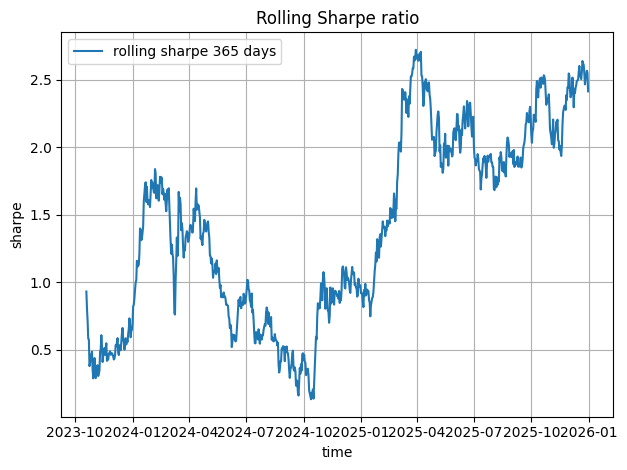

,timestamp,gross_return_daily,total_cost,net_return,cumulative,rolling_sharpe
0,2023-01-01 00:00:00+00:00,-0.016526,0.000000,-0.016526,-0.016526,NaN
1,2023-01-02 00:00:00+00:00,-0.030616,3.000000,-0.030916,-0.046932,NaN
2,2023-01-03 00:00:00+00:00,-0.027175,1.000000,-0.027275,-0.072927,NaN
3,2023-01-04 00:00:00+00:00,-0.008052,2.910714,-0.008343,-0.080661,NaN
4,2023-01-05 00:00:00+00:00,-0.010371,0.000000,-0.010371,-0.090195,NaN
...,...,...,...,...,...,...
1091,2025-12-27 00:00:00+00:00,0.006131,2.083333,0.005922,4.583911,2.514487
1092,2025-12-28 00:00:00+00:00,0.022023,0.000000,0.022023,4.706883,2.533270
1093,2025-12-29 00:00:00+00:00,0.016584,0.000000,0.016584,4.801525,2.567657
1094,2025-12-30 00:00:00+00:00,-0.004375,0.666667,-0.004442,4.775756,2.550842


In [35]:
def rolling_sharpe(last_cost, window = 365):
    temp = last_cost.copy()
    
    min_period = int(0.8*365)
    ann_factor = np.sqrt(window)
    
    roll_mean = temp["net_return"].rolling(window = window, min_periods = min_period).mean()
    roll_std = temp['net_return'].rolling(window = window, min_periods = min_period).std()
    
    temp["rolling_sharpe"] = (roll_mean / roll_std) * ann_factor
    
    plt.plot(temp["timestamp"] ,temp["rolling_sharpe"], label = f"rolling sharpe {window} days" )
    plt.title("Rolling Sharpe ratio") 
    plt.xlabel("time")
    plt.ylabel("sharpe")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    
    return temp

rolling_sharpe(last_cost)

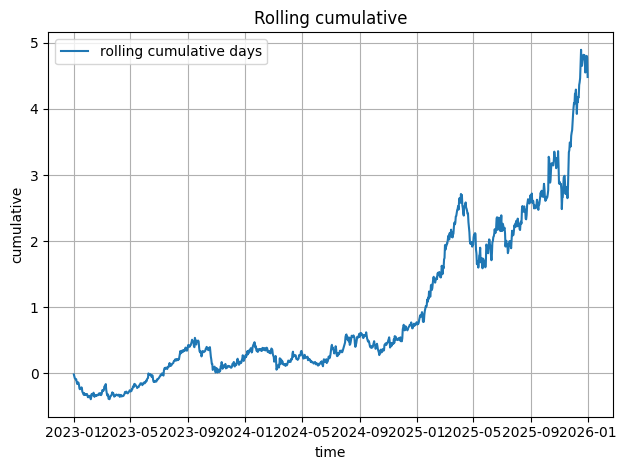

In [36]:
plt.plot(last_cost["timestamp"] ,last_cost["cumulative"], label = f"rolling cumulative days" )
plt.title("Rolling cumulative") 
plt.xlabel("time")
plt.ylabel("cumulative")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
    